In [34]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [35]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

DATA_PATH = (

    "../data/interim/"
    "emails_cleaned.csv"
)

df = pd.read_csv(

    DATA_PATH,

    keep_default_na=False
)

print(

    df.shape
)

df.head()

(5755, 10)


,label,subject,from,to,date,content_type,body,email_length,clean_text,clean_text_length
0,ham,Re: New Sequences Window,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700","text/plain; charset=""us-ascii""","Date: Wed, 21 Aug 2002 10:54:46 -0500\n...",1598,date wed aug chri garrigu messageid cant repro...,808
1,ham,[zzzzteana] RE: Alexander,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100","text/plain; charset=""US-ASCII""","Martin A posted:\nTassos Papadopoulos, the Gre...",894,martin post tasso papadopoulo greek sculptor b...,399
2,ham,[zzzzteana] Moscow bomber,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100","text/plain; charset=""US-ASCII""",Man Threatens Explosion In Moscow \n\nThursday...,1746,man threaten explos moscow thursday august pm ...,902
3,ham,[IRR] Klez: The Virus That Won't Die,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,"Thu, 22 Aug 2002 09:15:25 -0400","text/plain; charset=""us-ascii""",Klez: The Virus That Won't Die\n \nAlready the...,1125,klez viru wont die alreadi prolif viru ever kl...,590
4,ham,Re: [zzzzteana] Nothing like mama used to make,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100","text/plain; charset=""US-ASCII""","> in adding cream to spaghetti carbonara, whi...",1047,ad cream spaghetti carbonara effect pasta make...,464


In [36]:
# =========================================================
# DATASET OVERVIEW
# =========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5755 entries, 0 to 5754
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   label              5755 non-null   str  
 1   subject            5755 non-null   str  
 2   from               5755 non-null   str  
 3   to                 5755 non-null   str  
 4   date               5755 non-null   str  
 5   content_type       5755 non-null   str  
 6   body               5755 non-null   str  
 7   email_length       5755 non-null   int64
 8   clean_text         5755 non-null   str  
 9   clean_text_length  5755 non-null   int64
dtypes: int64(2), str(8)
memory usage: 449.7 KB


In [37]:
# =========================================================
# CHECK MISSING VALUES
# =========================================================

df.isnull().sum()

label                0
subject              0
from                 0
to                   0
date                 0
content_type         0
body                 0
email_length         0
clean_text           0
clean_text_length    0
dtype: int64

In [38]:
# =========================================================
# LABEL DISTRIBUTION
# =========================================================

df["label"].value_counts()

label
ham     3895
spam    1860
Name: count, dtype: int64

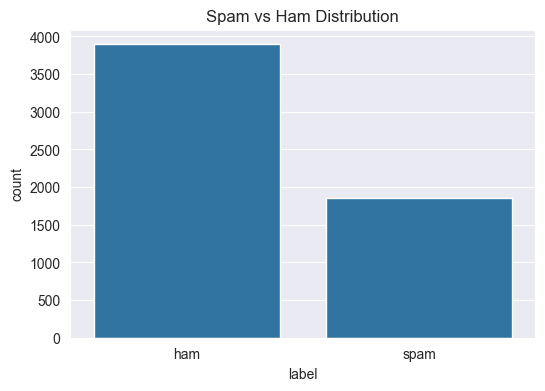

In [39]:
# =========================================================
# VISUALIZE LABEL DISTRIBUTION
# =========================================================

plt.figure(

    figsize=(6, 4)
)

sns.countplot(

    x="label",

    data=df
)

plt.title(

    "Spam vs Ham Distribution"
)

plt.show()

In [40]:
# =========================================================
# EMAIL LENGTH STATISTICS
# =========================================================

df["email_length"].describe()

count      5755.000000
mean       2249.287228
std        5632.677373
min          29.000000
25%         617.500000
50%        1097.000000
75%        2052.500000
max      202499.000000
Name: email_length, dtype: float64

In [41]:
# =========================================================
# CLEAN TEXT LENGTH STATISTICS
# =========================================================

df["clean_text_length"].describe()

count      5755.000000
mean        905.008341
std        2678.584808
min          12.000000
25%         252.000000
50%         464.000000
75%         813.000000
max      109915.000000
Name: clean_text_length, dtype: float64

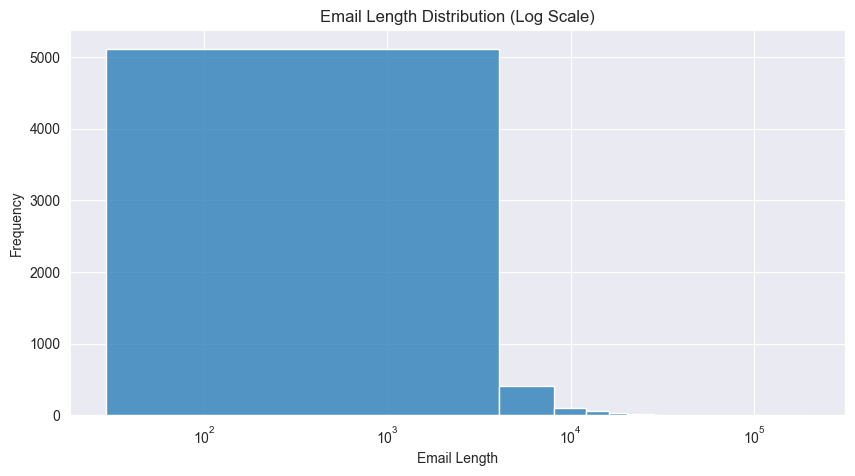

In [42]:
# =========================================================
# EMAIL LENGTH DISTRIBUTION
# =========================================================

plt.figure(

    figsize=(10, 5)
)

sns.histplot(

    df["email_length"],

    bins=50
)

plt.xscale("log")

plt.title(

    "Email Length Distribution (Log Scale)"
)

plt.xlabel(

    "Email Length"
)

plt.ylabel(

    "Frequency"
)

plt.show()

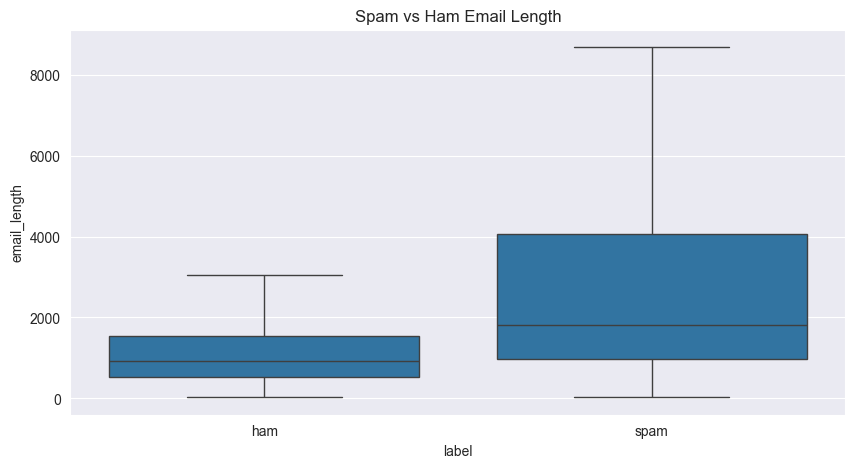

In [43]:
# =========================================================
# SPAM VS HAM EMAIL LENGTHS
# =========================================================

plt.figure(

    figsize=(10, 5)
)

sns.boxplot(

    x="label",

    y="email_length",

    data=df,

    showfliers=False
)

plt.title(

    "Spam vs Ham Email Length"
)

plt.show()

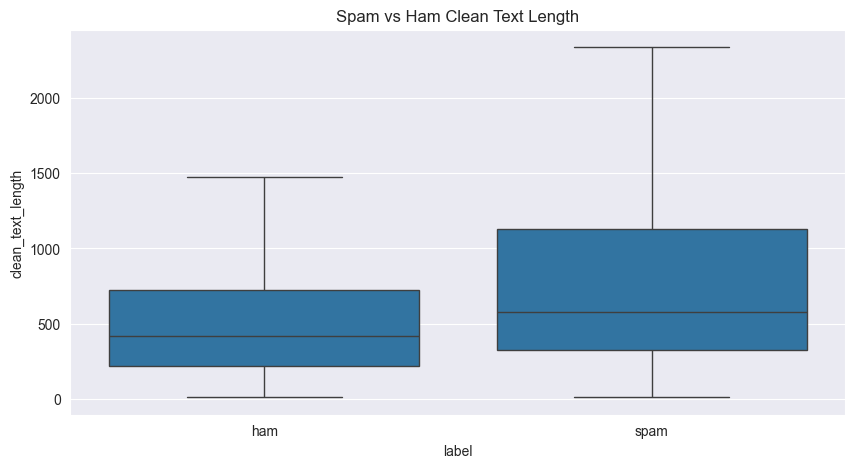

In [44]:
# =========================================================
# CLEAN TEXT LENGTH COMPARISON
# =========================================================

plt.figure(

    figsize=(10, 5)
)

sns.boxplot(

    x="label",

    y="clean_text_length",

    data=df,

    showfliers=False
)

plt.title(

    "Spam vs Ham Clean Text Length"
)

plt.show()

In [45]:
# =========================================================
# MOST COMMON WORDS
# =========================================================

def get_top_words(text_series, top_n=20):

    """
    Returns most common words.

    Args:
        text_series:
            Pandas Series containing text.

        top_n:
            Number of top words.

    Returns:
        DataFrame:
            Top words with counts.
    """

    all_words = " ".join(

        text_series
    ).split()

    word_counts = Counter(

        all_words
    )

    top_words = word_counts.most_common(

        top_n
    )

    return pd.DataFrame(

        top_words,

        columns=[

            "word",

            "count"
        ]
    )

In [46]:
# =========================================================
# TOP HAM WORDS
# =========================================================

ham_words = get_top_words(

    df[df["label"] == "ham"]["clean_text"]
)

ham_words

,word,count
0,use,3631
1,list,2773
2,mail,2108
3,messag,1803
4,work,1784
5,time,1725
6,wrote,1678
7,file,1563
8,dont,1544
9,new,1482


In [47]:
# =========================================================
# TOP SPAM WORDS
# =========================================================

spam_words = get_top_words(

    df[df["label"] == "spam"]["clean_text"]
)

spam_words

,word,count
0,email,4398
1,free,2476
2,size,2224
3,receiv,1841
4,order,1828
5,busi,1748
6,list,1738
7,address,1711
8,pleas,1709
9,money,1582


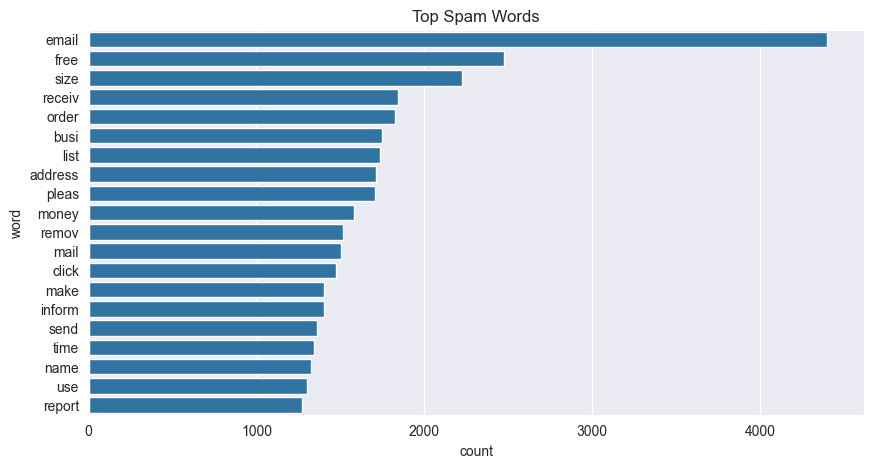

In [48]:
# =========================================================
# VISUALIZE TOP SPAM WORDS
# =========================================================

plt.figure(

    figsize=(10, 5)
)

sns.barplot(

    x="count",

    y="word",

    data=spam_words
)

plt.title(

    "Top Spam Words"
)

plt.show()

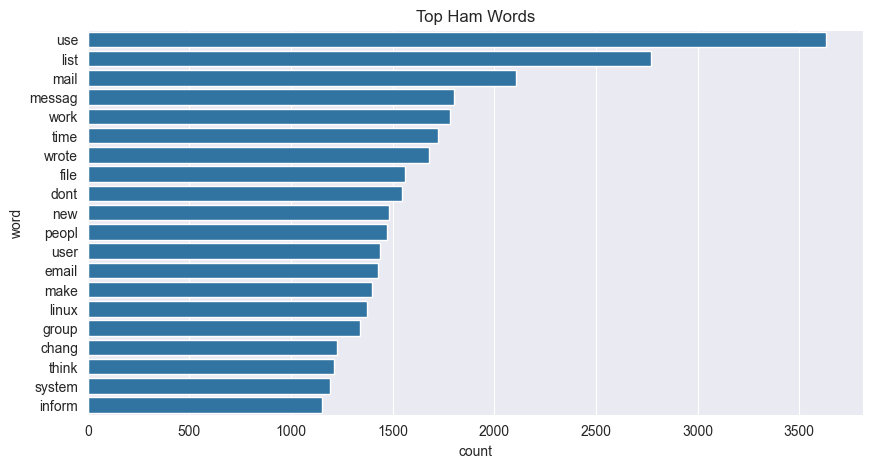

In [49]:
# =========================================================
# VISUALIZE TOP HAM WORDS
# =========================================================

plt.figure(

    figsize=(10, 5)
)

sns.barplot(

    x="count",

    y="word",

    data=ham_words
)

plt.title(

    "Top Ham Words"
)

plt.show()